In [1]:
import uproot
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
#import h5py

In [3]:
directory = "/N/project/phonon/PHONON_Bkgnds/job_submission/multisim/7444755/"
tree_name1 = "DetectorNeutrons"
tree_name2 = "Hits"
tree_name3 = "Primary"

pattern1 = f"{directory}/*.root:{tree_name1}"
pattern2 = f"{directory}/*.root:{tree_name2}"
pattern3 = f"{directory}/*.root:{tree_name3}"

dfs4 = []
dfs5 = []
dfs = []

print("Starting transfer of neutrons")
for chunk_dfs4 in uproot.iterate(pattern1,library="pd", step_size="250 MB"):
    dfs4.append(chunk_dfs4)
print("neutrons complete, moving to hits")
for chunk_dfs5 in uproot.iterate(pattern2,library="pd", step_size="250 MB"):
    dfs5.append(chunk_dfs5)
print("hits complete, doing primaries")
for chunk_dfs in uproot.iterate(pattern3,library="pd", step_size="250 MB"):
    dfs.append(chunk_dfs)
print("transfer done, concatenating dataframes")
df4 = pd.concat(dfs4, ignore_index=True)
print("done concat neutrons, concat hits")
df5 = pd.concat(dfs5, ignore_index=True)
print("done concat hits, concat primaries")
df = pd.concat(dfs, ignore_index=True)
print("Done.")

#file = uproot.open("/N/project/phonon/PHONON_Bkgnds/job_submission/multisim/7104869/sum_neutron_planarsource.root")
#tree = file["Primary"]
#tree2 = file["WaterNeutrons"]
#tree3 = file["AirNeutrons"]
#tree4 = file["DetectorNeutrons"]
#tree5 = file["Hits"]

#df = tree.arrays(library="pd")
#df2 = tree2.arrays(library="pd")
#df3 = tree3.arrays(library="pd")
#df4 = tree4.arrays(library="pd")
#df5 = tree5.arrays(library="pd")

#df['ParticleName'] = df['ParticleName'].astype(str)


Starting transfer of neutrons
neutrons complete, moving to hits
hits complete, doing primaries
transfer done, concatenating dataframes
done concat neutrons, concat hits
done concat hits, concat primaries
Done.


In [3]:
#attempt to merge the primary energy here with the neutrons 
#merged_df = pd.merge(df2, df, on="EventID", how="inner")

#merged_df_fill = merged_df.fillna(method="ffill")
#print(merged_df_fill)

#merged_df2 = pd.merge(df3, df, on="EventID", how="inner")

#merged_df_fill2 = merged_df2.fillna(method="ffill")
#print(merged_df_fill2)

#merged_df3 = pd.merge(df3, df2, on="EventID", how="inner")
#merged_df_fill3 = merged_df3.fillna(method="ffill")
#print(merged_df_fill3)

print(df)
print(df4)

#merged_df4 = pd.merge(df4, df, on="EventID", how="inner")
merged_df4 = df.merge(df4, on=["EventID"], how="inner")
#print(merged_df4)

#merged_df_fill4 = merged_df4.fillna(method="ffill")
#print(merged_df_fill4)

#merged_df5 = pd.merge(df4, df5, on=["EventID"], how="inner")
merged_df5 = df4.merge(df5, on=["EventID"], how="inner")
#merged_df_fill5 = merged_df5.fillna(method="ffill")
print(merged_df5)

merged_df5["ParticleName"] = merged_df5["ParticleName"].astype(str)

            EventID  TrackID  PDGCode  PrimaryEnergy  PrimaryPosX  \
0         1000000.0      1.0   2112.0       0.595136       -510.0   
1         1000001.0      1.0   2112.0       4.389881       -510.0   
2         1000002.0      1.0   2112.0      17.047176       -510.0   
3         1000003.0      1.0   2112.0      15.181557       -510.0   
4         1000004.0      1.0   2112.0      17.516312       -510.0   
...             ...      ...      ...            ...          ...   
39999995  9999995.0      1.0   2112.0       7.383367       -510.0   
39999996  9999996.0      1.0   2112.0      18.775006       -510.0   
39999997  9999997.0      1.0   2112.0      11.442191       -510.0   
39999998  9999998.0      1.0   2112.0      17.959135       -510.0   
39999999  9999999.0      1.0   2112.0      19.871523       -510.0   

          PrimaryPosY  PrimaryPosZ  PrimaryMomentumX  PrimaryMomentumY  \
0         -188.767721   -44.040526          0.970581          0.198177   
1          469.120671  

In [9]:
import pyarrow as pa
import pyarrow.parquet as pq
table = pa.Table.from_pandas(df4)
table2 = pa.Table.from_pandas(df)
pq.write_table(table, "test.parquet")
pq.write_table(table2, "primaries.parquet")

In [18]:
import polars as pl
df_polars = pl.read_parquet("test.parquet")
print(df_polars)
df_polars2 = pl.read_parquet("primaries.parquet")
print(df_polars2)
df_polars_comb = df_polars2.join(df_polars, on="EventID", how="inner")
print(df_polars_comb)

shape: (23_100, 8)
┌────────────┬─────────┬─────────┬─────────────┬────────────┬────────────┬────────────┬────────────┐
│ EventID    ┆ TrackID ┆ PDGCode ┆ KineticEner ┆ PositionDi ┆ PositionDi ┆ PositionDi ┆ PrimaryEne │
│ ---        ┆ ---     ┆ ---     ┆ gy          ┆ rX         ┆ rY         ┆ rZ         ┆ rgy        │
│ f64        ┆ f64     ┆ f64     ┆ ---         ┆ ---        ┆ ---        ┆ ---        ┆ ---        │
│            ┆         ┆         ┆ f64         ┆ f64        ┆ f64        ┆ f64        ┆ f64        │
╞════════════╪═════════╪═════════╪═════════════╪════════════╪════════════╪════════════╪════════════╡
│ 1.000503e6 ┆ 1.0     ┆ 2112.0  ┆ 0.000004    ┆ -0.974725  ┆ -0.192214  ┆ -0.113868  ┆ 8.796679   │
│ 1.001246e6 ┆ 1.0     ┆ 2112.0  ┆ 1.6997e-8   ┆ -0.987253  ┆ 0.108913   ┆ 0.116062   ┆ 18.893252  │
│ 1.002663e6 ┆ 2.0     ┆ 2112.0  ┆ 2.22137     ┆ -0.984779  ┆ 0.1619     ┆ 0.06324    ┆ 15.761728  │
│ 1.009474e6 ┆ 1.0     ┆ 2112.0  ┆ 1.4266e-8   ┆ -0.971348  ┆ -0.237354 

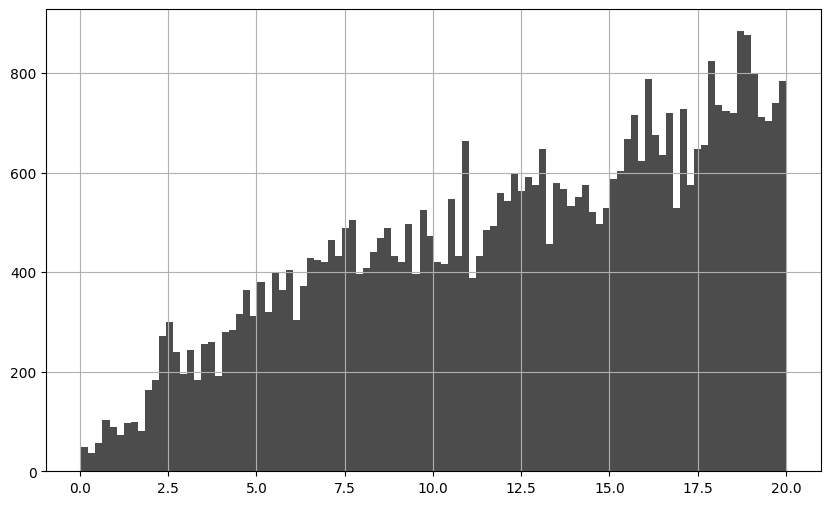

In [29]:
plt.figure(figsize=(10,6))
plt.hist(df_polars_comb["PrimaryEnergy"], bins=100, color='black', alpha=0.7)
#plt.title("Nb Nuclear Recoils from primary neutrons that reach the LiNbO3 block")
#plt.xlabel("cos(theta_x)")
#plt.ylabel("Frequency")
plt.grid()
#plt.savefig("NeutronTransfer_LiNbO3_planarsource_dirx.pdf")
plt.show()

In [27]:
import polars as pl
import polars_root as pr

df_pr = pr.read_root("/N/project/phonon/PHONON_Bkgnds/job_submission/multisim/7444755/sum_neutrons.root", "DetectorNeutrons")
print(df_pr)
df2_pr = pr.read_root("/N/project/phonon/PHONON_Bkgnds/job_submission/multisim/7444755/sum_neutrons.root", "Primary")
print(df2_pr)

df_comb = df2_pr.join(df_pr, on="EventID", how="inner")
print(df_comb)

shape: (11_550, 8)
┌─────────────┬─────────┬─────────┬────────────┬────────────┬────────────┬────────────┬────────────┐
│ EventID     ┆ TrackID ┆ PDGCode ┆ KineticEne ┆ PositionDi ┆ PositionDi ┆ PositionDi ┆ PrimaryEne │
│ ---         ┆ ---     ┆ ---     ┆ rgy        ┆ rX         ┆ rY         ┆ rZ         ┆ rgy        │
│ f64         ┆ f64     ┆ f64     ┆ ---        ┆ ---        ┆ ---        ┆ ---        ┆ ---        │
│             ┆         ┆         ┆ f64        ┆ f64        ┆ f64        ┆ f64        ┆ f64        │
╞═════════════╪═════════╪═════════╪════════════╪════════════╪════════════╪════════════╪════════════╡
│ 503.0       ┆ 1.0     ┆ 2112.0  ┆ 0.000004   ┆ -0.974725  ┆ -0.192214  ┆ -0.113868  ┆ 8.796679   │
│ 1246.0      ┆ 1.0     ┆ 2112.0  ┆ 1.6997e-8  ┆ -0.987253  ┆ 0.108913   ┆ 0.116062   ┆ 18.893252  │
│ 2663.0      ┆ 2.0     ┆ 2112.0  ┆ 2.22137    ┆ -0.984779  ┆ 0.1619     ┆ 0.06324    ┆ 15.761728  │
│ 9474.0      ┆ 1.0     ┆ 2112.0  ┆ 1.4266e-8  ┆ -0.971348  ┆ -0.237354 

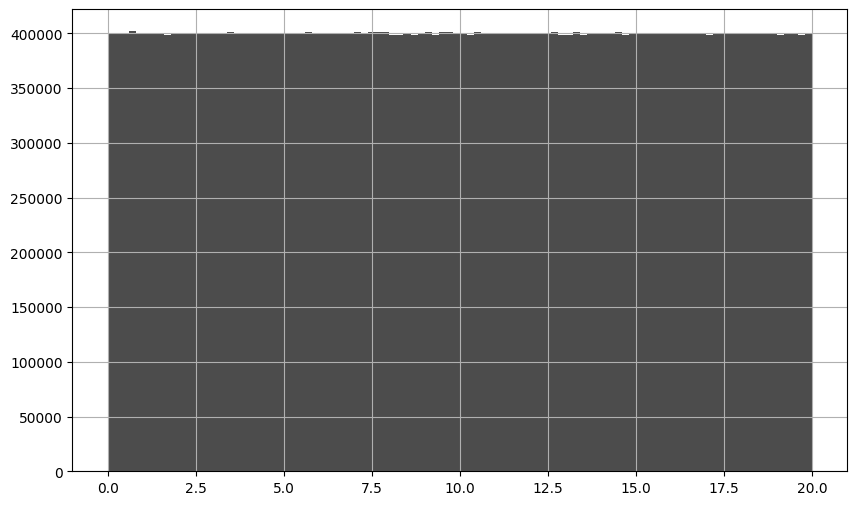

In [28]:
plt.figure(figsize=(10,6))
plt.hist(df2_pr["PrimaryEnergy"], bins=100, color='black', alpha=0.7)
#plt.title("Nb Nuclear Recoils from primary neutrons that reach the LiNbO3 block")
#plt.xlabel("cos(theta_x)")
#plt.ylabel("Frequency")
plt.grid()
#plt.savefig("NeutronTransfer_LiNbO3_planarsource_dirx.pdf")
plt.show()

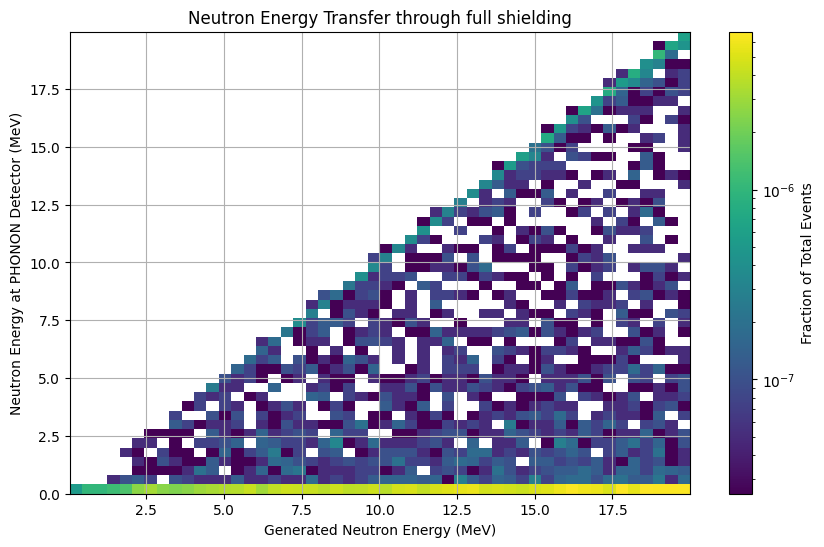

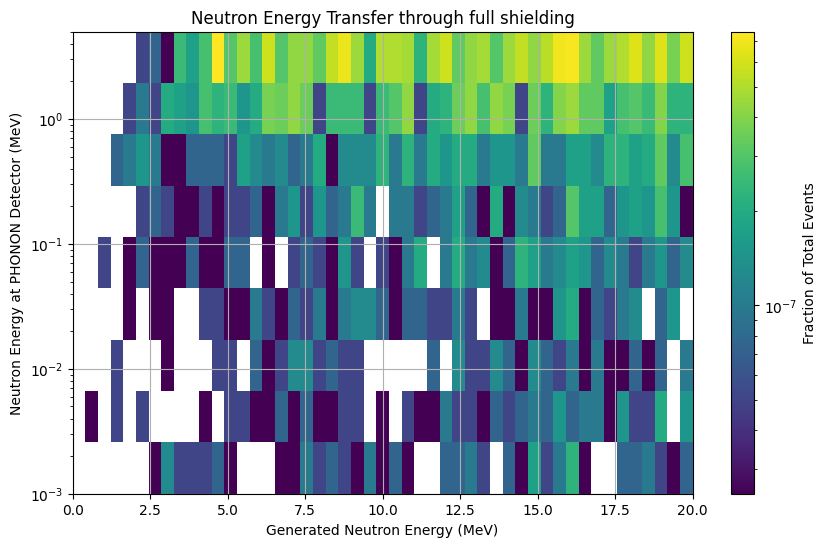

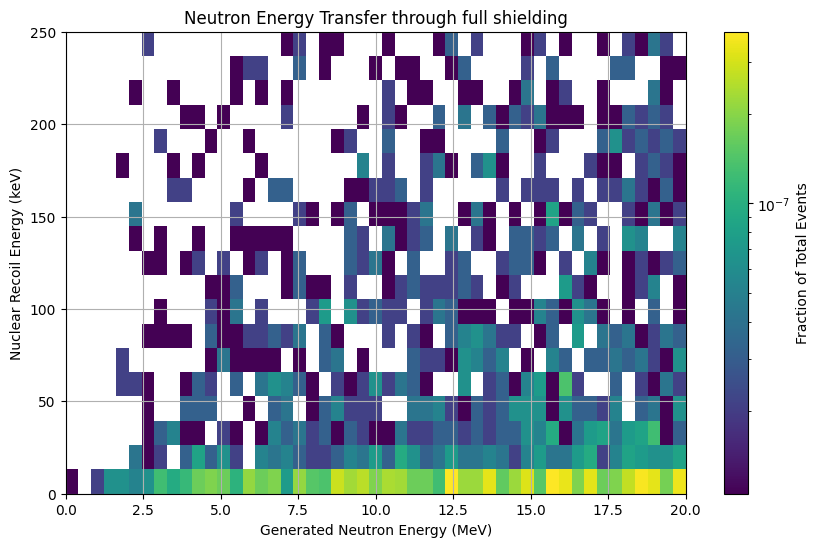

In [8]:
from matplotlib.colors import LogNorm
'''
heatmap, xedges, yedges = np.histogram2d(merged_df_fill['PrimaryEnergy'], merged_df_fill['KineticEnergy'], bins=50)
#heatmap = heatmap / heatmap.sum()
heatmap = heatmap / 5000000.0
heatmap = np.ma.masked_where(heatmap == 0, heatmap) 

plt.figure(figsize=(10, 6))
plt.scatter(merged_df_fill['PrimaryEnergy'], merged_df_fill['KineticEnergy'], alpha=0.5, s=1)
plt.title('Neutron Transfer Function through lead shielding')
plt.pcolormesh(xedges,yedges, heatmap.T, norm=LogNorm(), cmap="viridis")
plt.colorbar(label="Fraction of Total Events")
plt.xlabel('Primary Neutron Energy')
plt.ylabel('Neutron Energy at lead/water shield boundary')
plt.grid()
plt.savefig("NeutronTransfer_LeadWaterBoundary_5Mneutrons_costhebox_FracColorBar.pdf")
plt.show()

heatmap, xedges, yedges = np.histogram2d(merged_df_fill2['PrimaryEnergy'], merged_df_fill2['KineticEnergy'], bins=50)
#heatmap = heatmap / heatmap.sum()
heatmap = heatmap / 5000000.0
heatmap = np.ma.masked_where(heatmap == 0, heatmap) 

plt.figure(figsize=(10, 6))
plt.scatter(merged_df_fill2['PrimaryEnergy'], merged_df_fill2['KineticEnergy'], alpha=0.5, s=1)
plt.title('Neutron Transfer Function through water shielding')
plt.pcolormesh(xedges,yedges, heatmap.T, norm=LogNorm(), cmap="viridis")
plt.colorbar(label="Fraction of Total Events")
plt.xlabel('Primary Neutron Energy')
plt.ylabel('Neutron Energy at water shield/fridge boundary')
plt.grid()
plt.savefig("NeutronTransfer_WaterFridgeBoundary_5Mneutrons_costhebox_FracColorBar.pdf")
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(merged_df_fill3['KineticEnergy_x'], merged_df_fill3['KineticEnergy_y'], alpha=0.5, s=1)
plt.title('Neutron Transfer Function between shielding layers')
plt.xlabel('Neutron Energy at lead/water shield boundary')
plt.ylabel('Neutron Energy at water shield/fridge boundary')
plt.grid()
plt.show()
'''
#prim_mask = (merged_df4['TrackID_y'] == 1)

#prim_merged_df4 = merged_df4[prim_mask]
'''
heatmap, xedges, yedges = np.histogram2d(merged_df4['PrimaryEnergy_x'], merged_df4['KineticEnergy'], bins=50)
#heatmap = heatmap / heatmap.sum()
heatmap = heatmap / 95000000
heatmap = np.ma.masked_where(heatmap == 0, heatmap) 
plt.figure(figsize=(10, 6))
#plt.scatter(merged_df4['PrimaryEnergy'], merged_df4['KineticEnergy'], alpha=0.5, s=1)
#plt.imshow(merged_df4['PrimaryEnergy'], merged_df4['KineticEnergy'])
plt.title('Neutron Energy Transfer through full shielding')
plt.pcolormesh(xedges,yedges, heatmap.T, norm=LogNorm(), cmap="viridis")
plt.colorbar(label="Fraction of Total Events")
plt.xlabel('Generated Neutron Energy (MeV)')
plt.ylabel('Neutron Energy at PHONON Detector (MeV)')
plt.grid()
#plt.savefig("NeutronTransfer_FridgeDetectorBoundaryWafers_planarneutrons_FracColorBar.pdf")
plt.show()
'''
heatmap, xedges, yedges = np.histogram2d(df4['PrimaryEnergy'], df4['KineticEnergy'], bins=50)
#heatmap = heatmap / heatmap.sum()
heatmap = heatmap / len(df)
heatmap = np.ma.masked_where(heatmap == 0, heatmap) 
plt.figure(figsize=(10, 6))
plt.title('Neutron Energy Transfer through full shielding')
plt.pcolormesh(xedges,yedges, heatmap.T, norm=LogNorm(), cmap="viridis")
plt.colorbar(label="Fraction of Total Events")
plt.xlabel('Generated Neutron Energy (MeV)')
plt.ylabel('Neutron Energy at PHONON Detector (MeV)')
plt.grid()
plt.savefig("NeutronTransfer_FridgeDetectorBoundaryWafers_lowenergygen_lt20_neutrons_FracColorBar.pdf")
plt.show()

bins_x = np.linspace(0,20,num=50)

min = np.min(0.001)
max = np.max(5)
bins_y = np.logspace(np.log10(min), np.log10(max), num=10)

heatmap, xedges, yedges = np.histogram2d(df4['PrimaryEnergy'], df4['KineticEnergy'], bins=[bins_x, bins_y])
#heatmap = heatmap / heatmap.sum()
heatmap = heatmap / len(df)
heatmap = np.ma.masked_where(heatmap == 0, heatmap) 
plt.figure(figsize=(10, 6))
plt.title('Neutron Energy Transfer through full shielding')
plt.pcolormesh(xedges,yedges, heatmap.T, norm=LogNorm(), cmap="viridis")
plt.colorbar(label="Fraction of Total Events")
plt.xlabel('Generated Neutron Energy (MeV)')
plt.ylabel('Neutron Energy at PHONON Detector (MeV)')
plt.yscale('log')
plt.grid()
#plt.savefig("NeutronTransfer_FridgeDetectorBoundaryWafers_lowenergy_planarneutrons_FracColorBar.pdf")
plt.show()

mask = df['totalNR'] > 0.0001
df_masked = df[mask]
#print(df_masked)
bins_y = np.linspace(0,250, num=20)
heatmap, xedges, yedges = np.histogram2d(df_masked['PrimaryEnergy'], df_masked['totalNR']*1000.0, bins=[bins_x, bins_y])
#heatmap = heatmap / heatmap.sum()
heatmap = heatmap / 95000000.0
heatmap = np.ma.masked_where(heatmap == 0, heatmap) 
plt.figure(figsize=(10, 6))
plt.title('Neutron Energy Transfer through full shielding')
plt.pcolormesh(xedges,yedges, heatmap.T, norm=LogNorm(), cmap="viridis")
plt.colorbar(label="Fraction of Total Events")
plt.xlabel('Generated Neutron Energy (MeV)')
plt.ylabel('Nuclear Recoil Energy (keV)')
#plt.yscale('log')
plt.grid()
plt.savefig("NeutronTransfer_FridgeDetectorBoundaryWafers_nrenergy_lowenergygen_lt20_neutrons_FracColorBar.pdf")
plt.show()



[799745 801225 799910 800230 797926 800229 800411 800212 802118 798993
 798944 799871 800346 800919 801129 800590 799306 800483 801044 802559
 797387 798725 801107 799849 801458 798959 801473 799439 799441 800220
 799828 801496 797819 799640 800512 800001 799343 800911 799161 799925
 799330 800262 798012 799581 800589 800523 800959 798908 800371 798581]
[8.00937402e-07 4.00000762e-01 8.00000724e-01 1.20000068e+00
 1.60000065e+00 2.00000061e+00 2.40000057e+00 2.80000053e+00
 3.20000049e+00 3.60000045e+00 4.00000041e+00 4.40000038e+00
 4.80000034e+00 5.20000030e+00 5.60000026e+00 6.00000022e+00
 6.40000018e+00 6.80000014e+00 7.20000010e+00 7.60000007e+00
 8.00000003e+00 8.39999999e+00 8.79999995e+00 9.19999991e+00
 9.59999987e+00 9.99999983e+00 1.03999998e+01 1.07999998e+01
 1.11999997e+01 1.15999997e+01 1.19999996e+01 1.23999996e+01
 1.27999996e+01 1.31999995e+01 1.35999995e+01 1.39999994e+01
 1.43999994e+01 1.47999994e+01 1.51999993e+01 1.55999993e+01
 1.59999993e+01 1.63999992e+01 1.6

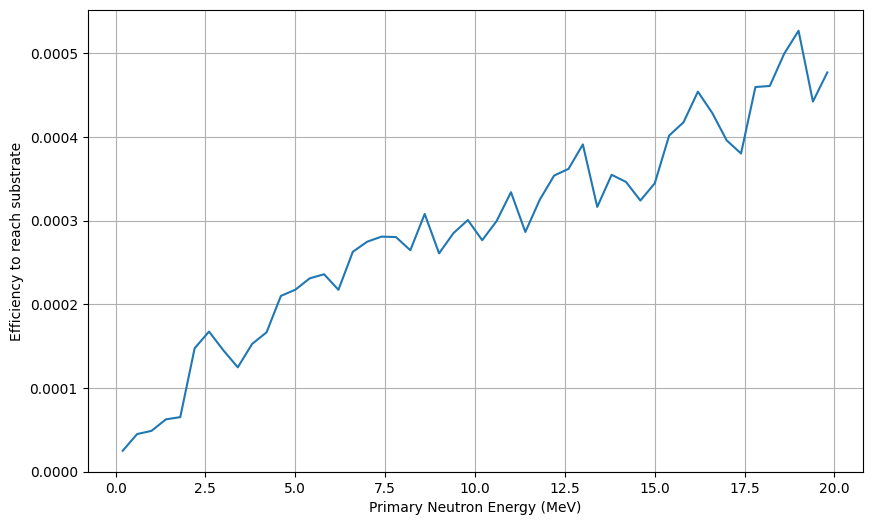

In [9]:
#generate binning in same way as above plot for primary energy to setup looking for hits in the scintillator 
#do for both overall neutrons and neutrons that enter the detector
#Look for both hits in 0-150 keV individually and also total NR for LiNbO3 block events
bins_num = 50
Emin, Emax = df['PrimaryEnergy'].min(), df['PrimaryEnergy'].max()
counts_den, edges = np.histogram(df['PrimaryEnergy'], bins=bins_num, range=(Emin, Emax))
print(counts_den)
print(edges)

bin_centers = (edges[:-1] + edges[1:]) / 2.0

new_counts, _ = np.histogram(df4['PrimaryEnergy'], bins=bins_num, range=(Emin, Emax))
print(new_counts)

eff_vals = np.divide(new_counts, counts_den)
print(eff_vals)

plt.figure(figsize=(10,6))
plt.plot(bin_centers, eff_vals, '-')
plt.title("")
plt.xlabel("Primary Neutron Energy (MeV)")
plt.ylabel("Efficiency to reach substrate")
plt.grid()
plt.savefig("test_efficiency_wafers_substrate_lowenergyneutrons_lt20.pdf")
plt.show()

[0 0 0 0 0 1 0 1 2 2 0 3 2 1 0 2 4 6 3 2 0 3 3 4 4 8 0 2 5 0 4 4 4 5 3 1 2
 2 1 1 6 4 6 1 7 3 9 3 2 2]


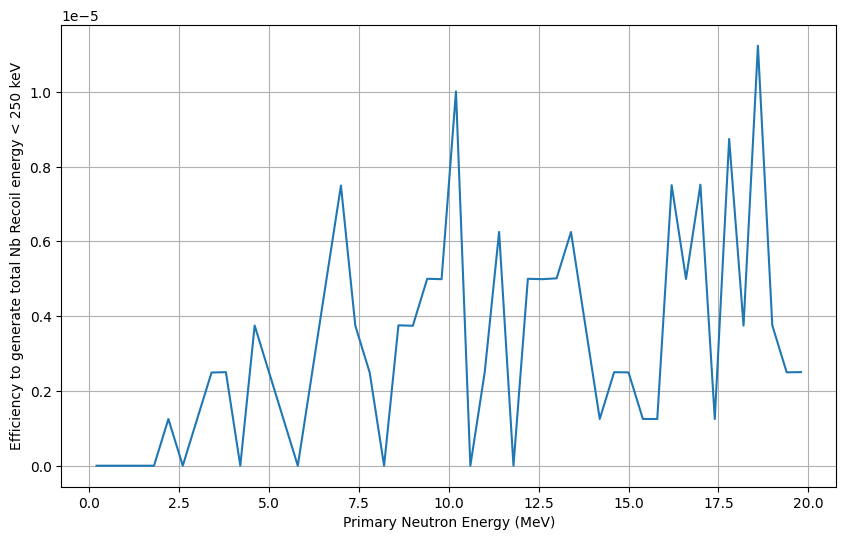

[  4   0   2   6  33  52  15  42  15  12  17  49  77  50  71  46  83  36
  96  56  50 102  37  67 100 145  38  92  49  74  81  63  67 151 115 133
 205 201 130 132 150 129 155 186 146 230 176 197 108  85]


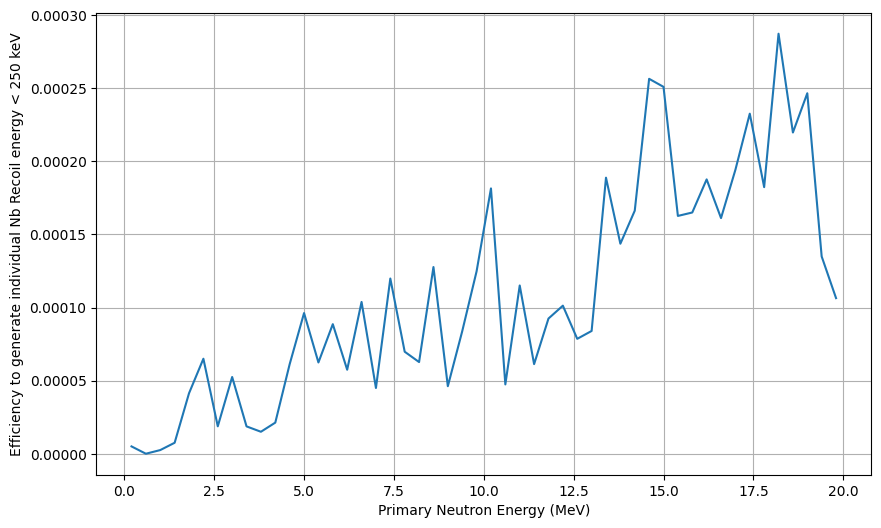

In [10]:
mask_nb = merged_df5["ParticleName"].str.contains('Nb', case=False, na=False)
mask_nr = merged_df5["ParticleName"].str.contains('Nb', case=False, na=False) | merged_df5["ParticleName"].str.contains('Li', case=False, na=False) | merged_df5["ParticleName"].str.contains('O', case=False, na=False)
nb_recoil_df = merged_df5[mask_nb]
nr_recoil_df = merged_df5[mask_nr]

mask_nb_roi = (merged_df5["Edep"] > 0.001) & (merged_df5["Edep"] < 0.25)

nb_roi_df = merged_df5[mask_nb_roi]
nr_roi_df = merged_df5[mask_nb_roi]

mask_nb_total = (merged_df4["totalNb"] > 0.001) & (merged_df4["totalNb"] < 0.25)
mask_nr_total = (merged_df4["totalNR"] > 0.001) & (merged_df4["totalNR"] < 0.25)

total_nb_df = merged_df4[mask_nb_total]
total_nr_df = merged_df4[mask_nr_total]

#attempt to create efficiency plot for neutrons generating Nb recoils of < 150 keV, both total and individual
new_counts, _ = np.histogram(total_nb_df['PrimaryEnergy_x'], bins=bins_num, range=(Emin, Emax))
print(new_counts)

eff_vals = np.divide(new_counts,counts_den)
plt.figure(figsize=(10,6))
plt.plot(bin_centers, eff_vals, '-')
plt.title("")
plt.xlabel("Primary Neutron Energy (MeV)")
plt.ylabel("Efficiency to generate total Nb Recoil energy < 250 keV")
plt.grid()
plt.savefig("efficiency_wafers_substrate_Nb_recoils_lowenergyneutrons_lt20.pdf")
plt.show()

new_counts, _ = np.histogram(nb_roi_df['PrimaryEnergy'], bins=bins_num, range=(Emin, Emax))
print(new_counts)

eff_vals = np.divide(new_counts,counts_den)
plt.figure(figsize=(10,6))
plt.plot(bin_centers, eff_vals, '-')
plt.title("")
plt.xlabel("Primary Neutron Energy (MeV)")
plt.ylabel("Efficiency to generate individual Nb Recoil energy < 250 keV")
plt.grid()
plt.savefig("efficiency_wafers_substrate_individual_Nb_recoils_lowenergyneutrons_lt20.pdf")
plt.show()




/tmp/ipykernel_1967439/2885172683.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  total_nb_df["selected"] = pd.cut(total_nb_df["PrimaryEnergy_x"], bins=edges)
/tmp/ipykernel_1967439/2885172683.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for b, group in total_nb_df.groupby("selected"):


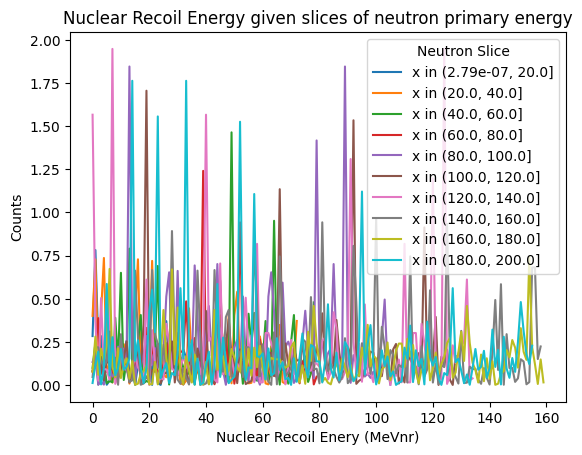

In [20]:
#plot total and individual recoil energy for given neutron primary energy
bins_num = 10
counts_den, edges = np.histogram(df['PrimaryEnergy'], bins=bins_num, range=(Emin, Emax))

total_nb_df["selected"] = pd.cut(total_nb_df["PrimaryEnergy_x"], bins=edges)
for b, group in total_nb_df.groupby("selected"):
    plt.plot(group["totalNR"].values, linestyle='-', label=f"x in {b}")
plt.xlabel("Nuclear Recoil Enery (MeVnr)")
plt.ylabel("Counts")
plt.title("Nuclear Recoil Energy given slices of neutron primary energy")
plt.legend(title="Neutron Slice")
plt.savefig("primary_neutron_slices_nrenergy.pdf")
plt.show()

In [21]:
def create_weights(counts_num, counts_den, edges, smooth=1e-12, clip=None, norm=""):
    denom = counts_den.astype(float)
    num = counts_num.astype(float)
    w = np.divide(num, denom, out=None, where=True)
    #w = np.divide(num, denom)
    if clip is not None:
        lo, hi = clip
        w = np.clip(w, lo, hi)
    if norm == "mean1":
        m = w.mean()
        if m > 0: w = w/m
    if norm == "sum1":
        s = w.sum()
        if s > 0: w = w/s
    return edges, w

def apply_weights(xs, edges, weights, underflow="extend", overflow="extend", default=1.0):
    xs = np.asarray(xs)
    idx = np.digitize(xs, edges, right=True) - 1 #creates a set from 0 to nbins-1
    nan_mask = ~np.isfinite(xs)
    idx = np.where(nan_mask, -1, idx)
    out = np.where(idx == -1, default, weights[idx])
    return out

In [22]:
#reweight on the neutrons by defining the power law, start with a area normalized version that I can scale by the actual flux value
#range is in MeV, flux value in something like n/MeV/m^2/us(spill) so I can normalize by the plane area and the time unit

def power_law(a, bins=100, rng=(0.01,200.0),density=False):
    lower_bound, upper_bound = float(rng[0]), float(rng[1])
    if upper_bound < lower_bound:
        raise ValueError("Upper bound must be greater than lower bound!")
    if isinstance(bins,int):
        edges = np.linspace(lower_bound, upper_bound, bins+1)
    else:
        edges = np.asarray(bins, dtype=float)
        if not np.all(np.diff(edges) > 0):
            raise ValueError("bin values must strictly increase!")
    widths = np.diff(edges)
    
    #compute the histogram
    pow_val = a + 1.0
    if lower_bound == 0 and a < -1:
        raise ValueError("cannot include lower_bound = 0 for a < -1 in this instance!")
    val_hi = edges[1:]**pow_val
    val_lo = edges[:-1]**pow_val
    denom = (upper_bound**pow_val) - (lower_bound**pow_val)
    prob = (val_hi - val_lo)/denom
    
    if density:
        hist = prob/widths
    else:
        hist = prob
    
            
    return hist, edges 

0.9999999999999999


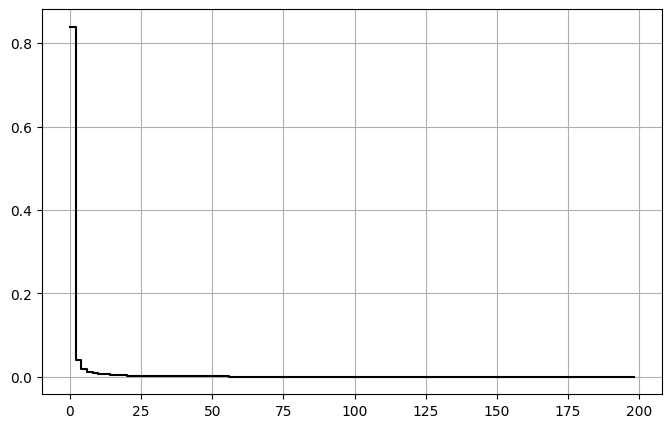

In [24]:
#generate normalized power law
h, e = power_law(-1.3)
#print(h)
print(np.sum(h))
#attempt a random scaling to check that as a concept, it works
#h = h * 1e3
plt.figure(figsize=(8,5))
plt.step(e[:-1], h, where="post", color="black")
plt.grid()
plt.show()

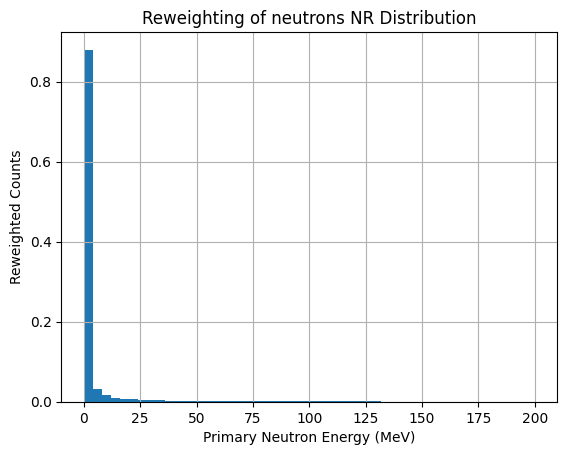

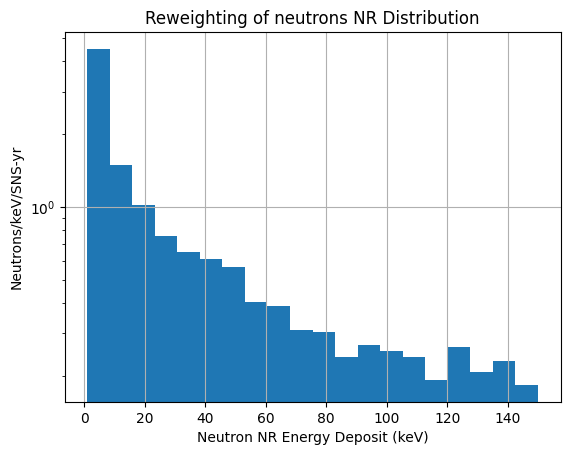

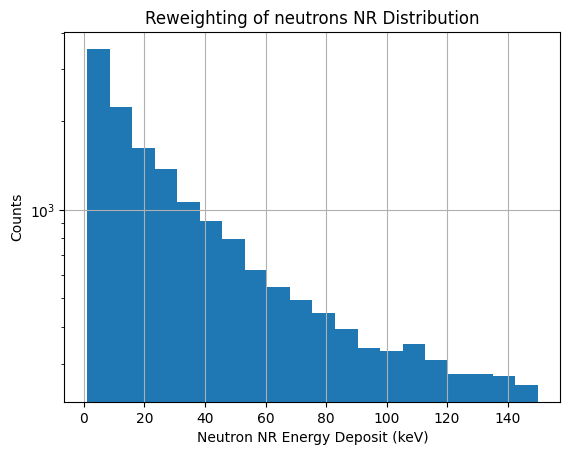

In [26]:
#with flux value from 2.5-40 MeV neutrons, restrict to that for now since we have defined flux
#mask_neutrons = (df_neutron['PrimaryEnergy'] > 2.5) & (df_neutron['PrimaryEnergy'] < 40.0)
#df_neutron_mask = df_neutron[mask_neutrons]

#now attempt a weighting with this using the original primaries
Emin, Emax = e.min(), e.max()
counts_den_neutron, edges_neutron = np.histogram(df['PrimaryEnergy'], bins=100, range=(Emin, Emax))
#generate weighting
fin_edges_neutron, weights_neutron = create_weights(h, counts_den_neutron, edges_neutron)

df['weights'] = apply_weights(df['PrimaryEnergy'], fin_edges_neutron, weights_neutron)
#merged_hits_neutrons['weights'] = apply_weights(merged_hits_neutrons['PrimaryEnergy'], fin_edges_neutron, weights_neutron)
#print(merged_hits_neutrons)
#this way works as I would expect, need to explore the merged dataframe better and understand that it is actually doing what I want
#with the stored weights it should be extendable to any variable that has the primary energy, might check that in each case common values give the same weight
plt.hist(df['PrimaryEnergy'], bins=50, range=(0.01, 200), weights=df['weights'])
plt.xlabel('Primary Neutron Energy (MeV)')
plt.ylabel('Reweighted Counts')
plt.title('Reweighting of neutrons NR Distribution')
#plt.yscale('log')
#plt.xscale('log')
plt.grid()
#plt.savefig('CEvNS_Reweighted_test_spectrum.pdf')
plt.show()

#mask = merged_hits_neutrons["totalNR"] > 0.0
#df_mask = merged_hits_neutrons[mask]

#scale the weights in order to get a full flux value
area = 1 #1 m^2 planar source
MWhr_per_yr = 7000 #assume 5000 hrs at 1.4 MW as in dukecevns calc
total_flux = 20 #in n/m^2/MWhr over the 2.5-40 MeV neutron energy range
df['weights'] = df['weights']*total_flux*area*MWhr_per_yr #convert to neutrons/SNS-year

#compute scale factor for /keV
bins_val = 20
lo, hi = 1, 150
width = (hi-lo)/(bins_val*1.0)
per_keV = width #convert to per keV

df['weights'] = df['weights']*per_keV

plt.hist(df['totalNR']*1000, bins=20, range=(1,150), weights=df['weights'])
plt.xlabel('Neutron NR Energy Deposit (keV)')
plt.ylabel('Neutrons/keV/SNS-yr')
plt.title('Reweighting of neutrons NR Distribution')
plt.yscale('log')
#plt.xscale('log')
plt.grid()
plt.savefig('Neutrons_weighted_LiNbO3_spectrum.pdf')
plt.show()

plt.hist(df['totalNR']*1000, bins=20, range=(1,150))
plt.xlabel('Neutron NR Energy Deposit (keV)')
plt.ylabel('Counts')
plt.title('Reweighting of neutrons NR Distribution')
plt.yscale('log')
#plt.xscale('log')
plt.grid()
plt.savefig('Neutrons_unweighted_LiNbO3_spectrum.pdf')
plt.show()





In [ ]:
plt.figure(figsize=(10,6))
plt.hist(nb_roi_df['Edep'], bins=100, color='black', alpha=0.7)
plt.title("Nb Nuclear Recoils from primary neutrons that reach the LiNbO3 block")
plt.xlabel("Energy Deposit (MeV)")
plt.ylabel("Frequency")
plt.yscale('log')
plt.grid()
plt.savefig("NuclearRecoil_hitlevelNb_planarneutrons.pdf")
plt.show()

plt.figure(figsize=(10,6))
plt.hist(nr_roi_df['Edep'], bins=100, color='black', alpha=0.7)
plt.title("Any Nuclear Recoils (Li, Nb, O) from primary neutrons that reach the LiNbO3 block")
plt.xlabel("Energy Deposit (MeV)")
plt.ylabel("Frequency")
plt.yscale('log')
plt.grid()
plt.savefig("NuclearRecoil_hitlevelNR_planarneutrons.pdf")
plt.show()


plt.figure(figsize=(10,6))
plt.hist(merged_df4['totalNb'], bins=100, color='blue', alpha=0.7)
plt.title("Total Nb Nuclear Recoil energy from primary neutron events that reach the LiNbO3 block")
plt.xlabel("Energy Deposit (MeV)")
plt.ylabel("Frequency")
plt.yscale('log')
plt.grid()
plt.savefig("NuclearRecoils_totalNR_planarneutrons.pdf")
plt.show()

plt.figure(figsize=(10,6))
plt.hist(merged_df4['totalNR'], bins=100, color='blue', alpha=0.7)
plt.title("Total energy from any Nuclear Recoils (Li, Nb, O) from primary neutron events that reach the LiNbO3 block")
plt.xlabel("Energy Deposit (MeV)")
plt.ylabel("Frequency")
plt.yscale('log')
plt.grid()
plt.savefig("NuclearRecoils_totalNR_planarneutrons.pdf")
plt.show()

plt.figure(figsize=(10,6))
plt.hist(total_nb_df['totalNb'], bins=100, color='red', alpha=0.7)
plt.title("Total Nb Nuclear Recoil energy from primary neutron events that reach the LiNbO3 block")
plt.xlabel("Energy Deposit (MeV)")
plt.ylabel("Frequency")
plt.yscale('log')
plt.grid()
#plt.savefig("NuclearRecoils_totalNR_planarneutrons.pdf")
plt.show()

plt.figure(figsize=(10,6))
plt.hist(total_nr_df['totalNR'], bins=100, color='red', alpha=0.7)
plt.title("Total energy from any Nuclear Recoils (Li, Nb, O) from primary neutron events that reach the LiNbO3 block")
plt.xlabel("Energy Deposit (MeV)")
plt.ylabel("Frequency")
plt.yscale('log')
plt.grid()
plt.show()

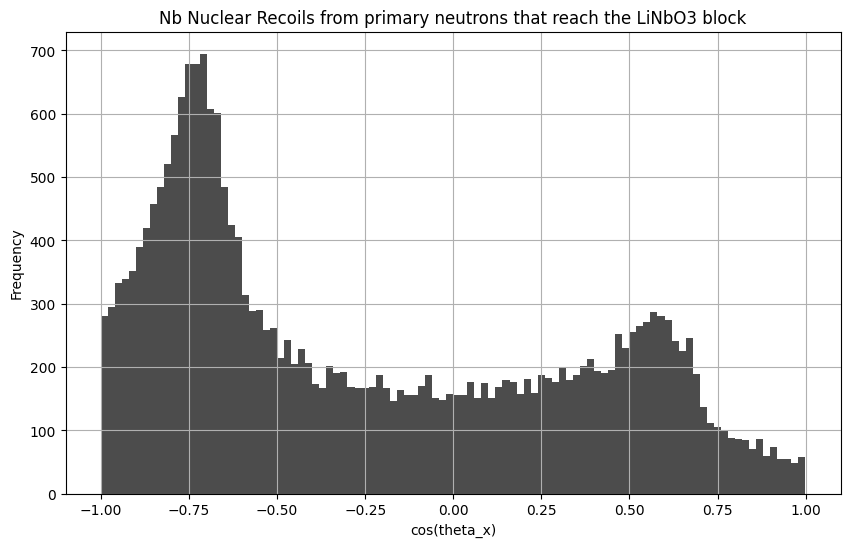

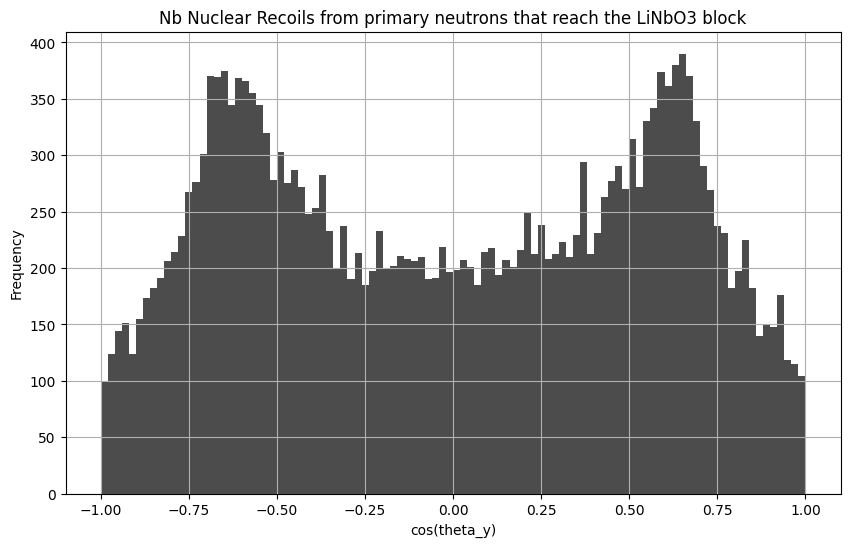

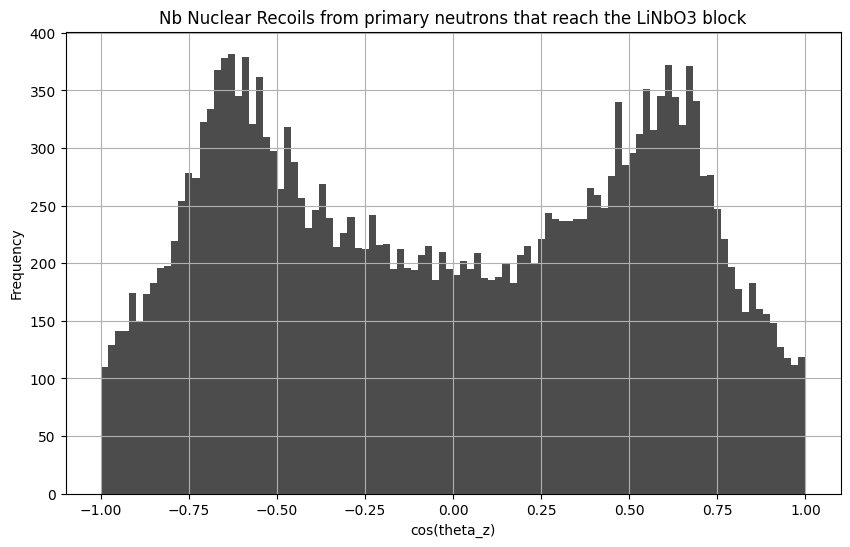

In [10]:
plt.figure(figsize=(10,6))
plt.hist(merged_df4['PositionDirX'], bins=100, color='black', alpha=0.7)
plt.title("Nb Nuclear Recoils from primary neutrons that reach the LiNbO3 block")
plt.xlabel("cos(theta_x)")
plt.ylabel("Frequency")
plt.grid()
plt.savefig("NeutronTransfer_LiNbO3_planarsource_dirx.pdf")
plt.show()

plt.figure(figsize=(10,6))
plt.hist(merged_df4['PositionDirY'], bins=100, color='black', alpha=0.7)
plt.title("Nb Nuclear Recoils from primary neutrons that reach the LiNbO3 block")
plt.xlabel("cos(theta_y)")
plt.ylabel("Frequency")
plt.grid()
plt.savefig("NeutronTransfer_LiNbO3_planarsource_diry.pdf")
plt.show()

plt.figure(figsize=(10,6))
plt.hist(merged_df4['PositionDirZ'], bins=100, color='black', alpha=0.7)
plt.title("Nb Nuclear Recoils from primary neutrons that reach the LiNbO3 block")
plt.xlabel("cos(theta_z)")
plt.ylabel("Frequency")
plt.grid()
plt.savefig("NeutronTransfer_LiNbO3_planarsource_dirz.pdf")
plt.show()